<a href="https://colab.research.google.com/github/Shahrukh2016/LangChain_LangGraph_LangSmith_Revision/blob/main/2_Revision_LangGraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!sudo apt-get update -qq && sudo apt-get install -y zstd -qq
!curl -fsSLs https://ollama.com/install.sh | sh
!nohup ollama serve > ollama.log 2>&1 &
!ollama pull llama3.2:1b
!ollama pull qwen:0.5b
!ollama pull qwen3-embedding:0.6b

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package zstd.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...
>>> Installing ollama to /usr/local
>>> Downloading ol

In [2]:
!ollama ls

NAME                    ID              SIZE      MODIFIED               
qwen3-embedding:0.6b    ac6da0dfba84    639 MB    Less than a second ago    
qwen:0.5b               b5dc5e784f2a    394 MB    8 seconds ago             
llama3.2:1b             baf6a787fdff    1.3 GB    18 seconds ago            


In [3]:
!pip install -q langchain langchain-core langchain-classic langchain-huggingface langchain-ollama langchain-community langchain-ollama pydantic pydantic[email] grandalf pypdf pymupdf langchain_text_splitters langchain-experimental langchain-chroma chromadb --upgrade opentelemetry-api opentelemetry-sdk opentelemetry-exporter-otlp langchain-pinecone langgraph

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.5/349.5 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.9/178.9 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/

# 1. LangGraph:

#### 1.1 BMI Calculator

In [4]:
#### 1.1 BMI Calculator
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, START, END
from typing import TypedDict


In [5]:
## Define state
class BMIState(TypedDict):
  weight_kg: float
  height_m: float
  bmi: float

In [6]:
## defining python function that runs while executing node
def calculate_bmi(state: BMIState) -> BMIState:
  weight = state["weight_kg"]
  height = state["height_m"]
  bmi = weight/(height)**2
  state['bmi'] = round(bmi,2)
  return state

In [7]:
## Define graph
graph = StateGraph(BMIState)

## Add nodes to the graph
graph.add_node("calculate_bmi", calculate_bmi)

## Add edges to the graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', END)

## Compile the graph
workflow = graph.compile()

In [8]:
# Execute the graph
initial_state = {"weight_kg" : 80, "height_m" : 1.75}
final_state = workflow.invoke(initial_state)
print(final_state)

{'weight_kg': 80, 'height_m': 1.75, 'bmi': 26.12}


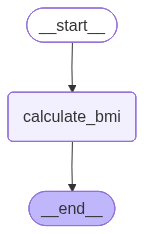

In [9]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

#### 1.2 BMI Labellor

In [10]:
#### 1.1 BMI Calculator
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

## Define state
class BMIState(TypedDict):
  weight_kg: float
  height_m: float
  bmi: float
  category: str

## defining python function that runs while executing node
def calculate_bmi(state: BMIState) -> BMIState:
  weight = state["weight_kg"]
  height = state["height_m"]
  bmi = weight/(height)**2
  state['bmi'] = round(bmi,2)
  return state

def calculate_label(state: BMIState) -> BMIState:
  bmi = state['bmi']
  if bmi < 18.5:
    state ["category"] = "Underweight"
  elif 18.5 <= bmi < 25:
    state["category"] = "Normal"
  elif 25 <= bmi < 30:
    state["category"] = "Overweight"
  else:
    state["category"] = "Obese"
  return state

## Define graph
graph = StateGraph(BMIState)

## Add nodes to the graph
graph.add_node("calculate_bmi", calculate_bmi)
graph.add_node("calculate_label", calculate_label)


## Add edges to the graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'calculate_label')
graph.add_edge('calculate_bmi', END)

## Compile the graph
workflow = graph.compile()


In [11]:
# Execute the graph
initial_state = {"weight_kg" : 80, "height_m" : 1.75}
final_state = workflow.invoke(initial_state)
print(final_state)

{'weight_kg': 80, 'height_m': 1.75, 'bmi': 26.12, 'category': 'Overweight'}


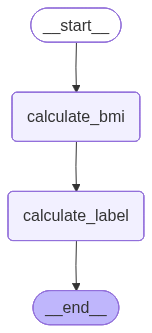

In [12]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

#### 1.3 LLM QnA

In [17]:
#### 1.3 Import
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

## Initialting the llm
model = ChatOllama(model = 'llama3.2:1b')

## Define state
class LLMQnA(TypedDict):
  question: str
  answer: str

## define function
def reply(state:LLMQnA) -> LLMQnA:
  question = state['question']
  state['answer'] = model.invoke(question)

## Define graph
graph = StateGraph(LLMQnA)

## Add nodes to the graph
graph.add_node("QnA", reply)

## Add edges to the graph
graph.add_edge(START, 'QnA')
graph.add_edge('QnA', END)

## Compile the graph
workflow = graph.compile()


In [ ]:
# Execute the graph
initial_state = {"question" : "What is the capital of India?"}
final_state = workflow.invoke(initial_state)
print(final_state)

In [ ]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())